In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

df = pd.read_csv('AI Job Market Dataset.csv')
df = df.dropna()
print(df.shape)
print(df.columns)
print(df.info())
print(df.isnull().sum())

(10345, 19)
Index(['job_id', 'job_title', 'company_size', 'company_industry', 'country',
       'remote_type', 'experience_level', 'years_experience',
       'education_level', 'skills_python', 'skills_sql', 'skills_ml',
       'skills_deep_learning', 'skills_cloud', 'salary', 'job_posting_month',
       'job_posting_year', 'hiring_urgency', 'job_openings'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   job_id                10345 non-null  int64 
 1   job_title             10345 non-null  object
 2   company_size          10345 non-null  object
 3   company_industry      10345 non-null  object
 4   country               10345 non-null  object
 5   remote_type           10345 non-null  object
 6   experience_level      10345 non-null  object
 7   years_experience      10345 non-null  int64 
 8   edu

In [ ]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])
    X = df.drop("salary", axis=1)
y = df["salary"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

R2 Score: 0.5602877818947593
MAE: 18368.879615554935
MSE: 437819484.698043


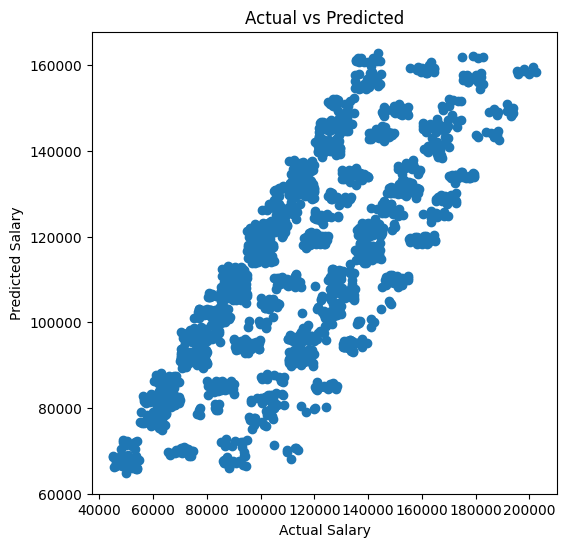

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")

plt.show()

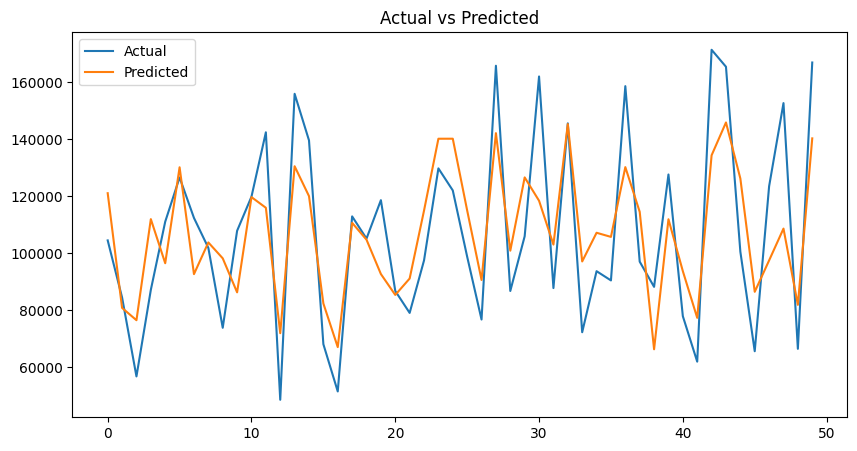

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:50], label="Actual")
plt.plot(y_pred[:50], label="Predicted")

plt.legend()
plt.title("Actual vs Predicted")

plt.show()

Accuracy: 0.0


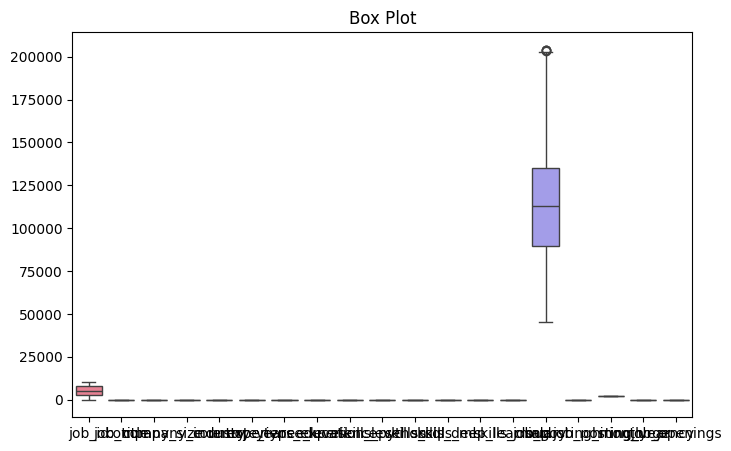

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model = DecisionTreeClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)
plt.figure(figsize=(8,5))

sns.boxplot(data=df)

plt.title("Box Plot")

plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)
import numpy as np

rmse = np.sqrt(mse)

print("Root Mean Squared Error:", rmse)

Mean Squared Error: 916187610.4934751
Root Mean Squared Error: 30268.591154751077


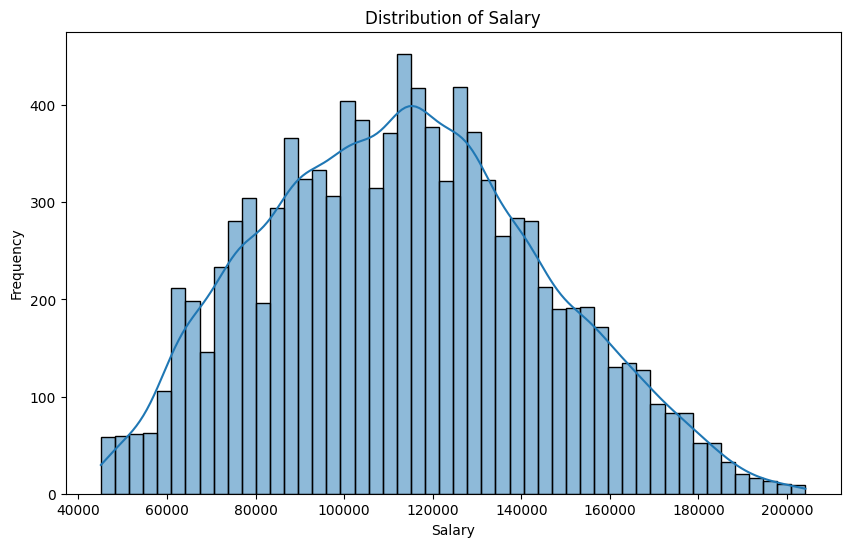

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['salary'], bins=50, kde=True)
plt.title('Distribution of Salary')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

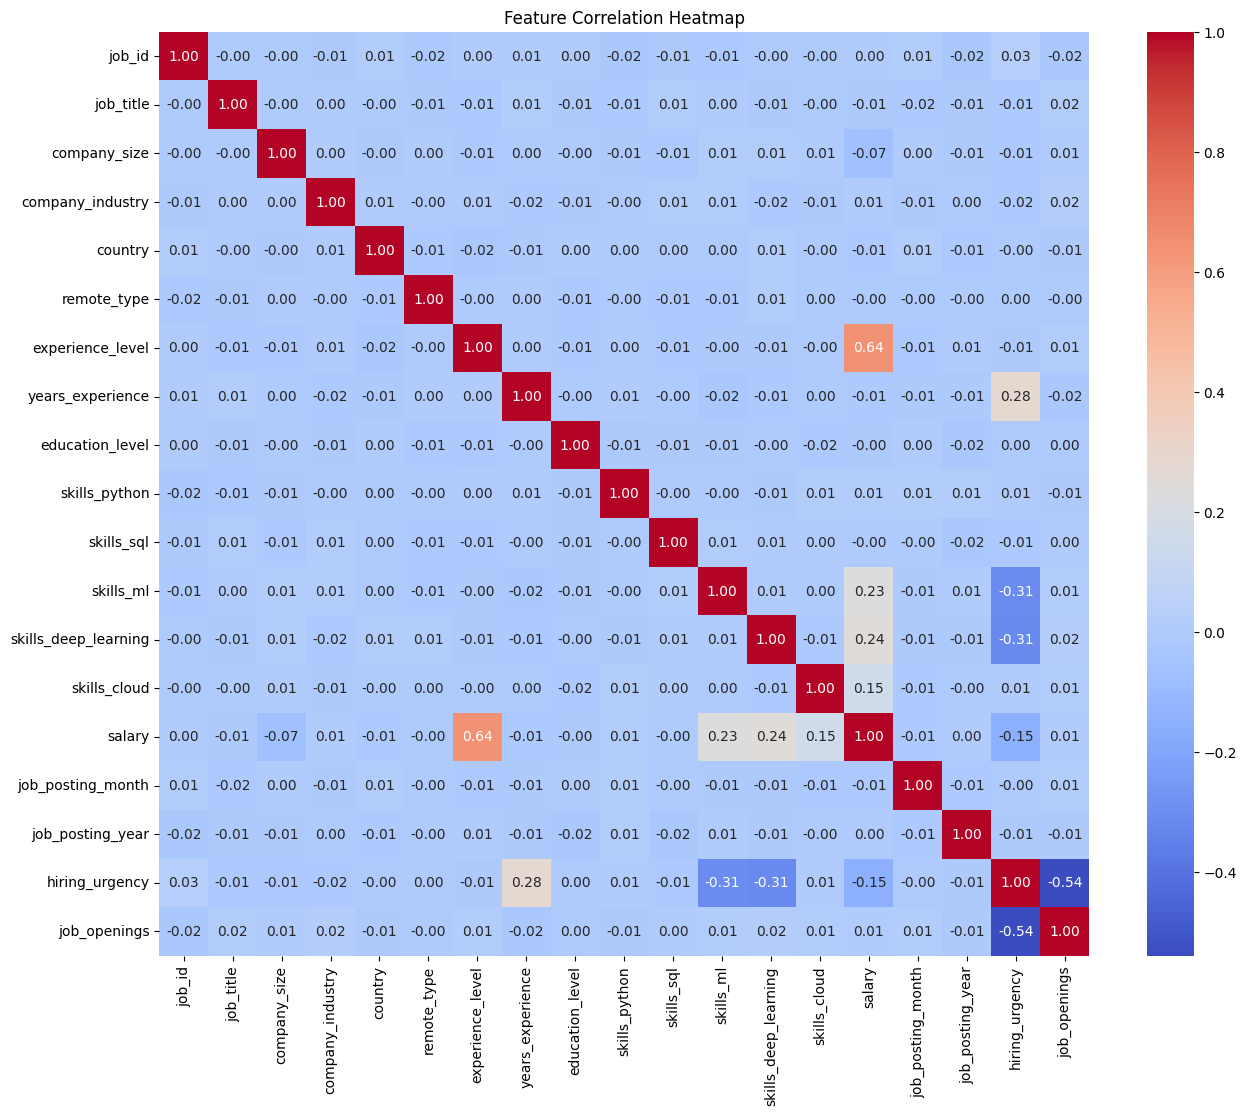

In [ ]:
plt.figure(figsize=(15, 12))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

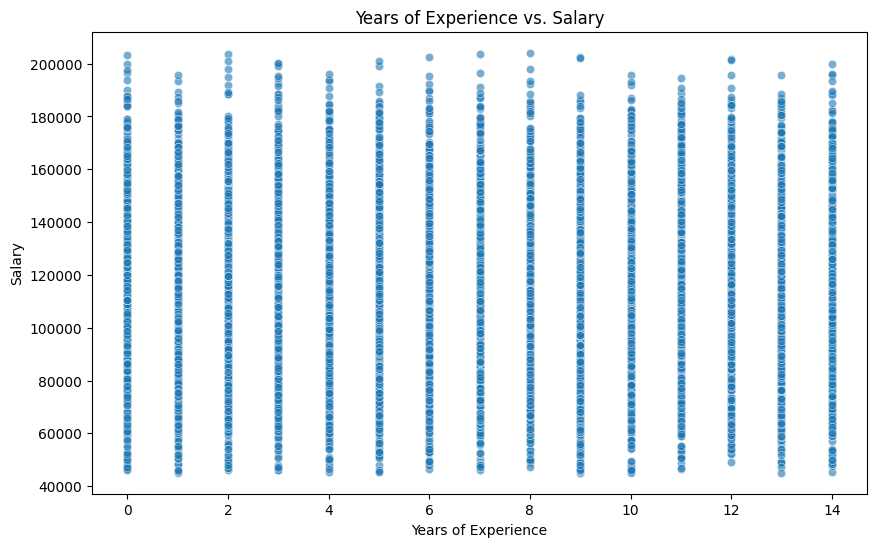

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='years_experience', y='salary', data=df, alpha=0.6)
plt.title('Years of Experience vs. Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

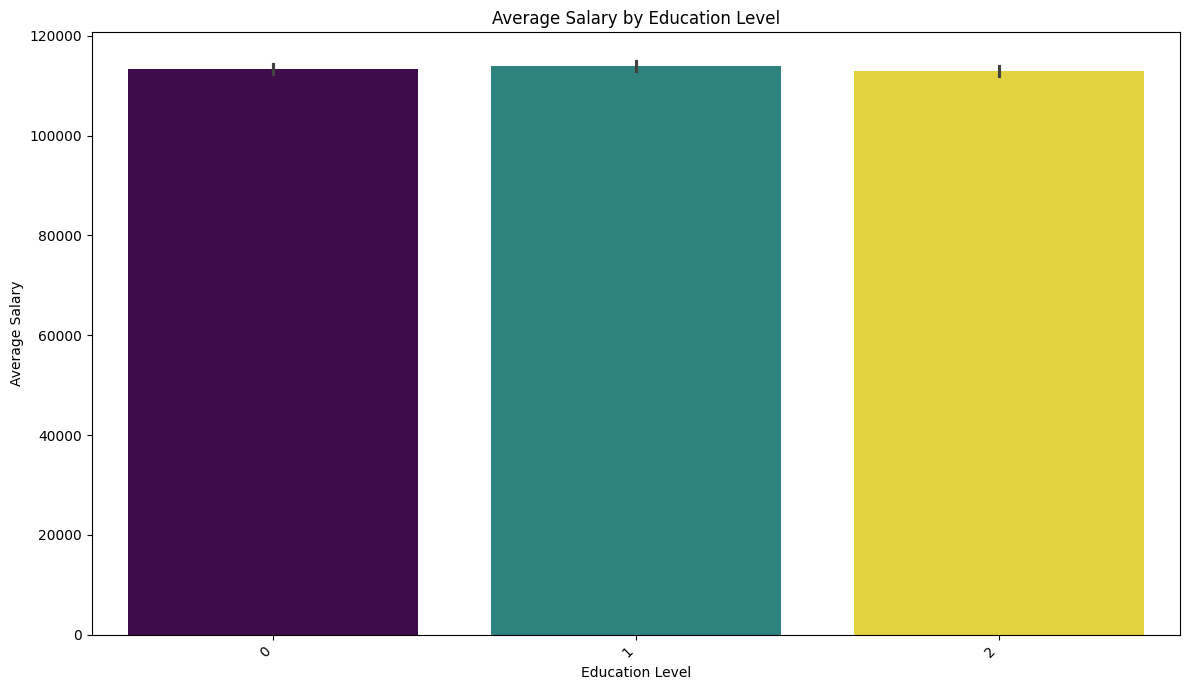

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='education_level', y='salary', data=df, hue='education_level', palette='viridis', legend=False)
plt.title('Average Salary by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Average Salary')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

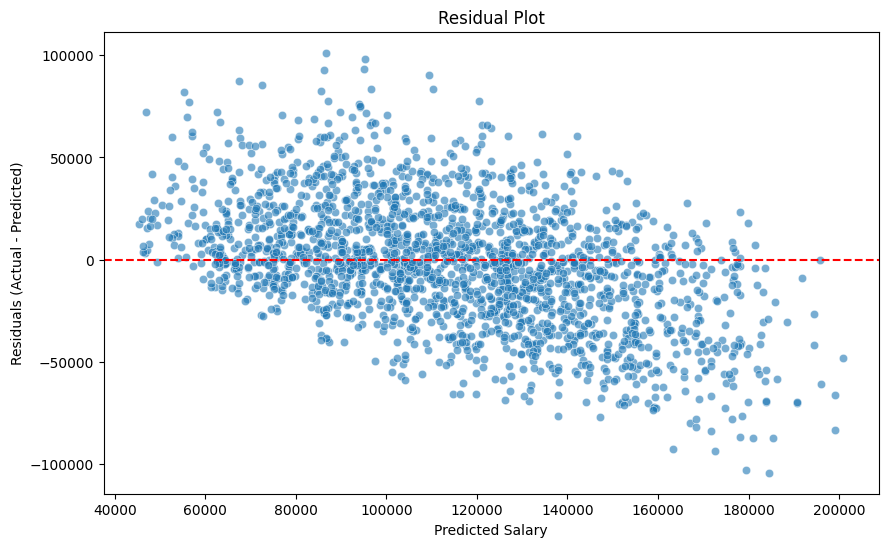

In [ ]:
# Residual Plot for Linear Regression
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Salary')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

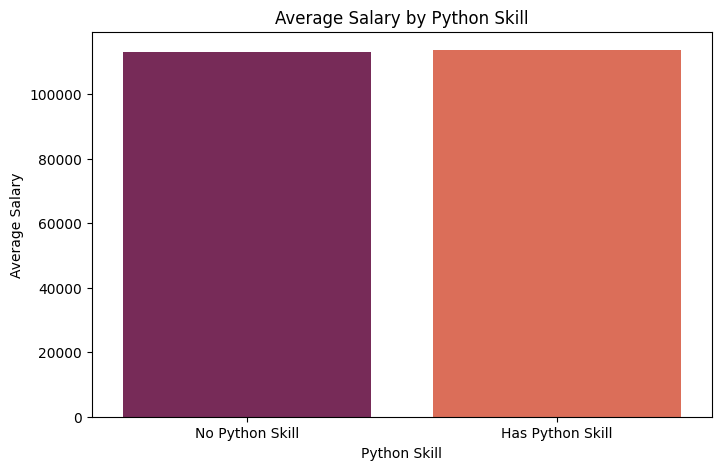

In [ ]:
# Average Salary by Python Skill
avg_salary_by_python_skill = df.groupby('skills_python')['salary'].mean().reset_index()
avg_salary_by_python_skill['skills_python_label'] = avg_salary_by_python_skill['skills_python'].map({0: 'No Python Skill', 1: 'Has Python Skill'})

plt.figure(figsize=(8, 5))
sns.barplot(x='skills_python_label', y='salary', data=avg_salary_by_python_skill, hue='skills_python_label', palette='rocket', legend=False)
plt.title('Average Salary by Python Skill')
plt.xlabel('Python Skill')
plt.ylabel('Average Salary')
plt.show()